In [23]:
import pandas as pd

sheets = pd.read_excel("indicatorsMY_v02.xlsx", sheet_name=None)

# Vérifie les noms des feuilles
print(sheets.keys())

# Exemple : afficher les premières lignes de la feuille 'Alternatives'
df = sheets['Alternatives']
df.shape

dict_keys(['Alternatives', 'Market_Indicators', 'Price_Level_BTC', 'Open_Interests_Futures', 'Money_Supply', 'Central_Banks_Balance_Sheets', 'Central_Banks_Policy_Rates', 'TED_Spreads', '3M_Gov__Bonds', 'Yield_Curve', 'Foreign_Exchange', 'Miscellaneous', 'Gross_Domestic_Products', 'Industrial_Production', 'Retail_Sales', 'Inflation', 'Economic Policy Uncertainty', 'News Based Policy Uncertainty', 'Economic_Surprises', 'Semiconductor_Market_Dynamics', 'Sentiment', 'OnChain'])


(136, 5869)

In [24]:
import pandas as pd

#ALLOWED_VARS = {"px_open","px_last","px_high","px_low","px_volume"}
DEFAULT_VAR = "px_last"  # variable par défaut pour les séries type Sentiment/OnChain

df_list = []

for name, sheet in sheets.items():
    sheet = sheet.dropna(how="all", axis=0).dropna(how="all", axis=1)
    if sheet.shape[1] < 3:
        continue

    a1 = str(sheet.columns[0]).strip().lower()
    b1 = str(sheet.columns[1]).strip().upper()

    # ======================================================
    # FORMAT PRIX (Alternatives, etc.)
    # A = Ticker | B = Variable | C.. = Dates
    # On garde UNIQUEMENT px_last
    # ======================================================
    if b1 == "DATES":
        tmp = sheet.copy()
        tmp.columns = ["Ticker", "Variable"] + list(tmp.columns[2:])

        tmp["Variable"] = tmp["Variable"].astype(str).str.strip()
        tmp = tmp[tmp["Variable"] == DEFAULT_VAR]   # <<< FILTRE ICI

        if tmp.empty:
            continue

        melted = tmp.melt(
            id_vars=["Ticker", "Variable"],
            var_name="Date",
            value_name="Value"
        )

    # ======================================================
    # FORMAT FEATURES (Sentiment / OnChain / Indices)
    # A = date | ligne suivante = feature
    # Variable forcée à px_last
    # ======================================================
    elif a1 == "date":
        tmp = sheet.copy()

        tmp = tmp.rename(columns={tmp.columns[0]: "Ticker"})
        tmp.insert(1, "Variable", DEFAULT_VAR)

        melted = tmp.melt(
            id_vars=["Ticker", "Variable"],
            var_name="Date",
            value_name="Value"
        )

    else:
        continue

    # ======================================================
    # Nettoyage
    # ======================================================
    melted["Date"] = pd.to_datetime(melted["Date"], errors="coerce")

    melted["Value"] = (
        melted["Value"]
        .astype(str)
        .str.replace(",", ".", regex=False)
        .str.replace(" ", "", regex=False)
        .str.replace("-", "", regex=False)
    )
    melted["Value"] = pd.to_numeric(melted["Value"], errors="coerce")

    melted = melted.dropna(subset=["Date", "Value"])

    melted["Ticker"] = melted["Ticker"].astype(str).str.strip()
    melted["Variable"] = DEFAULT_VAR
    melted["Category"] = name

    df_list.append(melted)

# ======================================================
# CONCATÉNATION FINALE
# ======================================================
merged_df = pd.concat(df_list, ignore_index=True)

print("Variables disponibles :", merged_df["Variable"].unique())
print("Nombre de tickers :", merged_df["Ticker"].nunique())


Variables disponibles : ['px_last']
Nombre de tickers : 200


In [25]:
merged_df[['Category', 'Ticker', 'Variable']].drop_duplicates().head(50)

,Category,Ticker,Variable
0,Alternatives,DXY Curncy,px_last
1,Alternatives,XAU Curncy,px_last
2,Alternatives,SPX Index,px_last
3,Alternatives,CCMP Index,px_last
4,Alternatives,RTY Index,px_last
5,Alternatives,CRY Index,px_last
6,Alternatives,SPGSCITR Index,px_last
7,Alternatives,SXXP Index,px_last
8,Alternatives,SHCOMP Index,px_last
14,Alternatives,LUATTRUU Index,px_last


In [26]:
merged_df["Value"].dtype, merged_df["Value"].head()

(dtype('float64'),
 0      76.12601
 1    1057.03000
 2    1076.19000
 3    2139.14000
 4     613.80500
 Name: Value, dtype: float64)

In [27]:
# Nettoyage global de la colonne Value
merged_df["Value"] = (
    merged_df["Value"]
    .astype(str)         # convertir en string
    .str.replace(",", ".")  # remplacer virgules
    .str.replace(" ", "")   # enlever espaces
    .str.replace("-", "")    # remplacer les tirets
)

# Conversion en float
merged_df["Value"] = pd.to_numeric(merged_df["Value"], errors="coerce")

In [28]:
# Convert all dates to datetime
merged_df["Date"] = pd.to_datetime(merged_df["Date"], errors="coerce")

# Force all dates to be timezone-naive
merged_df["Date"] = merged_df["Date"].dt.tz_localize(None)

In [29]:
pivot_df = merged_df.pivot_table(
    index="Date",
    columns="Ticker",
    values="Value",
    aggfunc='mean'   # corrige les doublons mélangés
)

corr = pivot_df.corr()
corr


Ticker,AdrActCnt,BASPTDSP Index,BDIY Index,BOJDPBAL Index,BlkCnt,CCMP Index,CESICNY Index,CESIEUR Index,CESIJPY Index,CESIUSD Index,...,mempool_growth,mempool_size_bytes,miner_revenue_usd,mining_difficulty,n_tx_excl_popular,price_usd,tx_fees_usd,tx_per_block,tx_per_second,utxo_count
Ticker,,,,,,,,,,,,,,,,,,,,,
AdrActCnt,1.000000,0.064268,0.485537,0.012550,0.060275,0.521500,0.054565,0.410257,0.145737,0.296581,...,0.284283,0.281877,0.571241,0.249534,0.392391,-0.093066,0.233444,0.391351,0.274072,0.357221
BASPTDSP Index,0.064268,1.000000,-0.272594,NaN,-0.021686,0.270147,0.031466,0.165858,-0.210168,0.020924,...,0.073628,-0.301102,-0.117918,-0.100492,0.176128,-0.074607,-0.132178,0.203814,0.104114,0.174945
BDIY Index,0.485537,-0.272594,1.000000,0.036977,-0.064568,0.233174,-0.069309,0.080409,0.179934,-0.050504,...,0.012354,0.069579,0.631556,0.258872,0.222923,-0.038660,0.163902,0.221326,0.132556,0.328236
BOJDPBAL Index,0.012550,NaN,0.036977,1.000000,-0.033794,0.576788,-0.117921,-0.148603,-0.136058,-0.169421,...,0.052043,-0.064148,0.394868,0.763197,0.352002,-0.012156,-0.051594,0.344349,0.165110,0.609678
BlkCnt,0.060275,-0.021686,-0.064568,-0.033794,1.000000,-0.111503,-0.101813,-0.059739,-0.098370,0.000024,...,0.040531,-0.027556,0.008288,-0.083498,-0.004266,-0.011690,0.005440,-0.111446,-0.001478,-0.073917
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
price_usd,-0.093066,-0.074607,-0.038660,-0.012156,-0.011690,-0.052698,-0.039370,-0.044269,-0.015391,-0.008558,...,-0.025197,-0.010471,-0.047317,-0.033123,-0.065255,1.000000,-0.014509,-0.070128,-0.031075,-0.056166
tx_fees_usd,0.233444,-0.132178,0.163902,-0.051594,0.005440,0.172853,-0.078823,0.139531,0.095097,0.059944,...,0.133237,0.378540,0.411672,0.125381,0.263347,-0.014509,1.000000,0.273559,0.175180,0.194710
tx_per_block,0.391351,0.203814,0.221326,0.344349,-0.111446,0.675226,-0.101149,0.026842,-0.146226,0.007678,...,0.299220,0.471387,0.498025,0.695349,0.877768,-0.070128,0.273559,1.000000,0.510983,0.788411


In [30]:
# Voir toutes les catégories disponibles
print("Catégories disponibles :")
print(merged_df['Category'].unique())
print("\nNombre total de catégories :", merged_df['Category'].nunique())

# Voir tous les tickers disponibles
print("\nTickers disponibles :")
print(merged_df['Ticker'].unique())
print("\nNombre total de tickers :", merged_df['Ticker'].nunique())

# Voir toutes les variables disponibles (px_open, px_last, etc.)
print("\nVariables disponibles :")
print(merged_df['Variable'].unique())
print("\nNombre total de variables :", merged_df['Variable'].nunique())

Catégories disponibles :
['Alternatives' 'Market_Indicators' 'Price_Level_BTC'
 'Open_Interests_Futures' 'Money_Supply' 'Central_Banks_Balance_Sheets'
 'Central_Banks_Policy_Rates' 'TED_Spreads' '3M_Gov__Bonds' 'Yield_Curve'
 'Foreign_Exchange' 'Miscellaneous' 'Gross_Domestic_Products'
 'Industrial_Production' 'Retail_Sales' 'Inflation'
 'Economic Policy Uncertainty' 'News Based Policy Uncertainty'
 'Economic_Surprises' 'Semiconductor_Market_Dynamics' 'Sentiment'
 'OnChain']

Nombre total de catégories : 22

Tickers disponibles :
['DXY Curncy' 'XAU Curncy' 'SPX Index' 'CCMP Index' 'RTY Index'
 'CRY Index' 'SPGSCITR Index' 'SXXP Index' 'SHCOMP Index' 'LUATTRUU Index'
 'LUACTRUU Index' 'LF98TRUU Index' 'NKY Index' 'XETUSD Curncy'
 'XLCUSD Curncy' 'XBNUSD Curncy' 'XRPUSD Curncy' 'XDGUSD Curncy'
 'XADUSD Curncy' 'XSOUSD Curncy' 'VIX Index' 'MOVE Index' 'CVIX Index'
 'RIOT US Equity' 'JPMVXYGL Index' 'MARA US Equity' 'CIFR US Equity'
 'IREN US Equity' 'CORZ US Equity' 'XBTUSD Curncy' 'CFC5Q

In [11]:
print(merged_df['Ticker'].nunique())

200


In [33]:
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, confusion_matrix
from collections import defaultdict

# ============================================================
# CONFIGURATION
# ============================================================

START_DATE = "2018-03-01"

# Split "logique" par date (train <= TRAIN_END_DATE, test > TRAIN_END_DATE)
TRAIN_END_DATE = "2023-12-31"

HORIZONS = [1, 14, 30, 60]
RETURN_TYPE = "simple"  # "simple" ou "log"

N_BINS = 5
SCENARIO_NAMES = ["Very Bear", "Bear", "Neutral", "Bull", "Very Bull"]

MIN_NON_NA_FRAC = 0.70   # après ffill
MIN_ROWS = 300

RF_CLASS_PARAMS = dict(
    n_estimators=400,
    max_depth=12,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# ============================================================
# TARGET: FUTURE RETURNS (NO LEAKAGE)
# ============================================================

def calculate_returns(prices: pd.Series, horizon: int, return_type: str = "simple") -> pd.Series:
    prices = prices.astype(float)
    future_price = prices.shift(-horizon)

    if return_type == "simple":
        return (future_price - prices) / prices
    elif return_type == "log":
        return np.log(future_price / prices)
    else:
        raise ValueError("return_type must be 'simple' or 'log'")

# ============================================================
# SCENARIO BINS (TRAIN-ONLY) -> NO LEAKAGE
# ============================================================

def fit_quantile_bins(train_returns: pd.Series, n_bins: int = 5) -> np.ndarray:
    x = train_returns.dropna().values
    if len(x) < 50:
        raise ValueError("Not enough training returns to fit bins")

    qs = np.quantile(x, np.linspace(0, 1, n_bins + 1))
    qs[0], qs[-1] = -np.inf, np.inf

    # éviter les bords identiques
    for i in range(1, len(qs)):
        if qs[i] <= qs[i - 1]:
            qs[i] = qs[i - 1] + 1e-12

    return qs

def apply_bins(returns: pd.Series, bins: np.ndarray) -> pd.Series:
    return pd.cut(returns, bins=bins, labels=False, include_lowest=True).astype("Int64")

# ============================================================
# EVALUATION (CLASSIFICATION ONLY, LEAKAGE SAFE, DATE SPLIT)
# ============================================================

def evaluate_horizon_classification_leakfree_by_date(
    pivot_df: pd.DataFrame,
    horizon: int,
    return_type: str = "simple",
    train_end_date: str = TRAIN_END_DATE,
    start_date: str = START_DATE
):
    df = pivot_df.copy()
    df.index = pd.to_datetime(df.index)
    df = df.sort_index()
    df = df[df.index >= pd.to_datetime(start_date)]

    # BTC column detection (robust)
    btc_candidates = ["XBTUSD Curncy", "XBTUSD"]
    btc_col = next((c for c in btc_candidates if c in df.columns), None)
    if btc_col is None:
        raise ValueError("Colonne BTC introuvable (attendu: 'XBTUSD Curncy' ou 'XBTUSD').")

    # ---------- Features: ffill ONLY (NO bfill) ----------
    df_features = df.ffill()

    # drop columns too incomplete after ffill
    thresh = int(MIN_NON_NA_FRAC * len(df_features))
    df_features = df_features.dropna(axis=1, thresh=thresh)

    # ---------- Target returns ----------
    returns = calculate_returns(df[btc_col], horizon, return_type=return_type)

    # build modeling frame
    df_model = df_features.copy()
    df_model["target_return"] = returns

    # remove rows where target not available (future missing)
    df_model = df_model.dropna(subset=["target_return"])
    if len(df_model) < MIN_ROWS:
        return None

    # split by date
    cut = pd.to_datetime(train_end_date)
    train_mask = df_model.index <= cut
    test_mask = df_model.index > cut

    if train_mask.sum() < MIN_ROWS or test_mask.sum() < 50:
        return None

    X_full = df_model.drop(columns=["target_return"])
    y_ret_full = df_model["target_return"].astype(float)

    # remove return-like columns (safety)
    X_full = X_full.drop(columns=[c for c in X_full.columns if "logret" in c.lower() or "logreturn" in c.lower()], errors="ignore")

    # remove BTC level EXACTLY (not contains)
    if btc_col in X_full.columns:
        X_full = X_full.drop(columns=[btc_col], errors="ignore")

    # split
    X_train = X_full.loc[train_mask].copy()
    X_test  = X_full.loc[test_mask].copy()
    y_ret_train = y_ret_full.loc[train_mask].copy()
    y_ret_test  = y_ret_full.loc[test_mask].copy()

    # train-only bins -> scenarios
    bins = fit_quantile_bins(y_ret_train, n_bins=N_BINS)
    y_train = apply_bins(y_ret_train, bins).dropna().astype(int)
    y_test  = apply_bins(y_ret_test, bins).dropna().astype(int)

    # align X with possible dropped rows
    X_train = X_train.loc[y_train.index]
    X_test  = X_test.loc[y_test.index]

    if X_train.shape[1] < 5:
        return None

    # scaling (fit train only)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled  = scaler.transform(X_test)

    # model
    clf = RandomForestClassifier(**RF_CLASS_PARAMS)
    clf.fit(X_train_scaled, y_train)
    y_pred = clf.predict(X_test_scaled)

    # metrics
    acc = float(accuracy_score(y_test, y_pred))
    bal_acc = float(balanced_accuracy_score(y_test, y_pred))
    macro_f1 = float(f1_score(y_test, y_pred, average="macro"))
    cm = confusion_matrix(y_test, y_pred, labels=list(range(N_BINS)))

    # full importances (not only top10)
    imp_full = pd.DataFrame({
        "feature": X_train.columns,
        "importance": clf.feature_importances_
    }).sort_values("importance", ascending=False).reset_index(drop=True)
    imp_full["rank"] = np.arange(1, len(imp_full) + 1)

    # useful stats: train/test returns
    ret_stats_train = {
        "mean": float(y_ret_train.mean()),
        "std": float(y_ret_train.std()),
        "min": float(y_ret_train.min()),
        "max": float(y_ret_train.max()),
        "skew": float(y_ret_train.skew()),
        "kurt": float(y_ret_train.kurtosis()),
    }
    ret_stats_test = {
        "mean": float(y_ret_test.mean()),
        "std": float(y_ret_test.std()),
        "min": float(y_ret_test.min()),
        "max": float(y_ret_test.max()),
        "skew": float(y_ret_test.skew()),
        "kurt": float(y_ret_test.kurtosis()),
    }

    return {
        "horizon": horizon,
        "btc_col_used": btc_col,
        "train_end_date": str(train_end_date),

        "n_train": int(len(y_train)),
        "n_test": int(len(y_test)),

        "acc": acc,
        "bal_acc": bal_acc,
        "macro_f1": macro_f1,
        "cm": cm,

        "top_features": imp_full.head(10),
        "imp_full": imp_full,

        "ret_stats_train": ret_stats_train,
        "ret_stats_test": ret_stats_test
    }

# ============================================================
# RUN MULTI-HORIZONS + SUMMARY + RECURRENT FEATURES
# ============================================================

print("=" * 95)
print("MULTI-HORIZON BTC SCENARIO CLASSIFICATION (LEAKAGE-FREE, DATE SPLIT)")
print(f"Train <= {TRAIN_END_DATE} | Test > {TRAIN_END_DATE}")
print("=" * 95)

all_results = []
feature_tracker = defaultdict(list)

for h in HORIZONS:
    print("\n" + "=" * 95)
    print(f"Horizon = {h} days")
    print("=" * 95)

    res = evaluate_horizon_classification_leakfree_by_date(
        pivot_df,
        horizon=h,
        return_type=RETURN_TYPE,
        train_end_date=TRAIN_END_DATE,
        start_date=START_DATE
    )

    if res is None:
        print("-> Not enough data / too few usable features with this date split.")
        continue

    all_results.append(res)

    print(f"BTC col used: {res['btc_col_used']}")
    print(f"Train N={res['n_train']} | Test N={res['n_test']}")
    print(f"Acc={res['acc']*100:.1f}% | BalAcc={res['bal_acc']*100:.1f}% | MacroF1={res['macro_f1']:.3f}")
    print("\nTop 10 features:")
    print(res["top_features"][["rank","feature","importance"]].to_string(index=False))

    for _, row in res["imp_full"].head(10).iterrows():
        feature_tracker[row["feature"]].append((h, float(row["importance"])))

# SUMMARY TABLE
if all_results:
    summary_df = pd.DataFrame([{
        "Horizon (d)": r["horizon"],
        "Train N": r["n_train"],
        "Test N": r["n_test"],
        "Acc (%)": r["acc"] * 100,
        "BalAcc (%)": r["bal_acc"] * 100,
        "MacroF1": r["macro_f1"],
        "Train mean ret": r["ret_stats_train"]["mean"],
        "Train std ret": r["ret_stats_train"]["std"],
        "Test mean ret": r["ret_stats_test"]["mean"],
        "Test std ret": r["ret_stats_test"]["std"],
    } for r in all_results]).sort_values("Horizon (d)")

    print("\n" + "=" * 95)
    print("SUMMARY")
    print("=" * 95)
    print(summary_df.to_string(index=False))

    print("\n" + "=" * 95)
    print("MOST RECURRENT FEATURES (top-20 across horizons, from top-10 each horizon)")
    print("=" * 95)

    feat_counts = {feat: len(v) for feat, v in feature_tracker.items()}
    for feat, count in sorted(feat_counts.items(), key=lambda x: x[1], reverse=True)[:20]:
        horizons_str = ", ".join([f"{h}d" for h, _ in feature_tracker[feat]])
        avg_imp = float(np.mean([imp for _, imp in feature_tracker[feat]]))
        print(f"{feat:35s} -> {count}/{len(HORIZONS)} horizons | avg_imp={avg_imp:.4f} | {horizons_str}")

else:
    print("No results (all horizons failed).")

# ============================================================
# OPTIONAL: CHECK IMPORTANCE FOR SPECIFIC FEATURES (e.g., RIOT, DXY)
# After running, you can do:
#
#   r = all_results[0]
#   r["imp_full"][r["imp_full"]["feature"].str.contains("RIOT|DXY", case=False, na=False)][["rank","feature","importance"]]
#
# ============================================================


MULTI-HORIZON BTC SCENARIO CLASSIFICATION (LEAKAGE-FREE, DATE SPLIT)
Train <= 2023-12-31 | Test > 2023-12-31

Horizon = 1 days
BTC col used: XBTUSD Curncy
Train N=1938 | Test N=673
Acc=21.2% | BalAcc=19.9% | MacroF1=0.120

Top 10 features:
 rank           feature  importance
    1   hashrate_7d_pct    0.018529
    2 active_addr_ratio    0.017426
    3               NVT    0.017155
    4            BlkCnt    0.016547
    5     XBNUSD Curncy    0.015849
    6          TxTfrCnt    0.015452
    7     tx_per_second    0.015334
    8         AdrActCnt    0.014922
    9             TxCnt    0.014724
   10     XLCUSD Curncy    0.014187

Horizon = 14 days
BTC col used: XBTUSD Curncy
Train N=2035 | Test N=660
Acc=24.2% | BalAcc=19.8% | MacroF1=0.111

Top 10 features:
 rank              feature  importance
    1        XBNUSD Curncy    0.022646
    2        XLCUSD Curncy    0.018689
    3           CapMVRVCur    0.016426
    4 days_to_next_halving    0.015573
    5   days_since_halving    0.01530

In [34]:
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, confusion_matrix
from sklearn.dummy import DummyClassifier
from collections import defaultdict

# ============================================================
# CONFIGURATION
# ============================================================

START_DATE = "2018-03-01"

# Split logique par date (pas juste 80/20 arbitraire)
# Exemple : train <= 2023-12-31, test > 2023-12-31
TRAIN_END_DATE = "2023-12-31"

HORIZONS = [1, 14, 30, 60]
RETURN_TYPE = "simple"  # "simple" ou "log"

N_BINS = 5
SCENARIO_NAMES = ["Very Bear", "Bear", "Neutral", "Bull", "Very Bull"]

# Drop colonnes trop incomplètes après ffill (réglable)
MIN_NON_NA_FRAC = 0.70

MIN_ROWS_TOTAL = 300     # dataset minimal après target
MIN_ROWS_TRAIN = 300     # train minimal
MIN_ROWS_TEST = 50       # test minimal

RF_CLASS_PARAMS = dict(
    n_estimators=400,
    max_depth=12,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# ============================================================
# TARGET: FUTURE RETURNS (NO LEAKAGE)
# ============================================================

def calculate_returns(prices: pd.Series, horizon: int, return_type: str = "simple") -> pd.Series:
    prices = prices.astype(float)
    future_price = prices.shift(-horizon)

    if return_type == "simple":
        return (future_price - prices) / prices
    elif return_type == "log":
        return np.log(future_price / prices)
    else:
        raise ValueError("return_type must be 'simple' or 'log'")

# ============================================================
# SCENARIO BINS (TRAIN-ONLY) -> NO LEAKAGE
# ============================================================

def fit_quantile_bins(train_returns: pd.Series, n_bins: int = 5) -> np.ndarray:
    x = train_returns.dropna().values
    if len(x) < 50:
        raise ValueError("Not enough training returns to fit bins")

    qs = np.quantile(x, np.linspace(0, 1, n_bins + 1))
    qs[0], qs[-1] = -np.inf, np.inf

    # avoid duplicate edges
    for i in range(1, len(qs)):
        if qs[i] <= qs[i - 1]:
            qs[i] = qs[i - 1] + 1e-12

    return qs

def apply_bins(returns: pd.Series, bins: np.ndarray) -> pd.Series:
    return pd.cut(returns, bins=bins, labels=False, include_lowest=True).astype("Int64")

# ============================================================
# EVALUATION (CLASSIFICATION ONLY, LEAKAGE SAFE, DATE SPLIT)
# ============================================================

def evaluate_horizon_classification_leakfree(pivot_df: pd.DataFrame, horizon: int, return_type: str = "simple"):
    df = pivot_df.copy()
    df.index = pd.to_datetime(df.index)
    df = df.sort_index()
    df = df[df.index >= pd.to_datetime(START_DATE)]

    # BTC column detection (robust)
    btc_candidates = ["XBTUSD Curncy", "XBTUSD"]
    btc_col = next((c for c in btc_candidates if c in df.columns), None)
    if btc_col is None:
        raise ValueError("Colonne BTC introuvable (attendu: 'XBTUSD Curncy' ou 'XBTUSD').")

    # -------- Features leakage-safe: ffill ONLY (NO bfill) --------
    df_features = df.ffill()

    # Drop columns too incomplete after ffill
    thresh = int(MIN_NON_NA_FRAC * len(df_features))
    df_features = df_features.dropna(axis=1, thresh=thresh)

    # -------- Target returns --------
    returns = calculate_returns(df[btc_col], horizon, return_type=return_type)

    # Build modeling frame
    df_model = df_features.copy()
    df_model["target_return"] = returns

    # remove rows where target is missing (future not available)
    df_model = df_model.dropna(subset=["target_return"])

    if len(df_model) < MIN_ROWS_TOTAL:
        return None

    X_full = df_model.drop(columns=["target_return"])
    y_ret_full = df_model["target_return"].astype(float)

    # Remove any return-like columns (safety)
    X_full = X_full.drop(
        columns=[c for c in X_full.columns if "logret" in c.lower() or "logreturn" in c.lower()],
        errors="ignore"
    )

    # Remove BTC level EXACTLY (évite de dropper des colonnes qui contiennent "XBTUSD" par accident)
    if btc_col in X_full.columns:
        X_full = X_full.drop(columns=[btc_col], errors="ignore")

    # -------- Split logique par DATE --------
    cut = pd.to_datetime(TRAIN_END_DATE)
    train_mask = X_full.index <= cut
    test_mask = X_full.index > cut

    if train_mask.sum() < MIN_ROWS_TRAIN or test_mask.sum() < MIN_ROWS_TEST:
        return None

    X_train = X_full.loc[train_mask].copy()
    X_test  = X_full.loc[test_mask].copy()
    y_ret_train = y_ret_full.loc[train_mask].copy()
    y_ret_test  = y_ret_full.loc[test_mask].copy()

    # -------- Train-only bins -> scenario labels (NO LEAKAGE) --------
    bins = fit_quantile_bins(y_ret_train, n_bins=N_BINS)
    y_train = apply_bins(y_ret_train, bins).dropna().astype(int)
    y_test  = apply_bins(y_ret_test, bins).dropna().astype(int)

    # align X with any dropped rows
    X_train = X_train.loc[y_train.index]
    X_test  = X_test.loc[y_test.index]

    if X_train.shape[1] < 5:
        return None

    # -------- Scaling (fit train only) --------
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled  = scaler.transform(X_test)

    # -------- Model --------
    clf = RandomForestClassifier(**RF_CLASS_PARAMS)
    clf.fit(X_train_scaled, y_train)
    y_pred = clf.predict(X_test_scaled)

    # -------- Metrics --------
    acc = float(accuracy_score(y_test, y_pred))
    bal_acc = float(balanced_accuracy_score(y_test, y_pred))
    macro_f1 = float(f1_score(y_test, y_pred, average="macro"))
    cm = confusion_matrix(y_test, y_pred, labels=list(range(N_BINS)))

    # -------- Dummy baseline (most frequent) --------
    dummy = DummyClassifier(strategy="most_frequent", random_state=42)
    dummy.fit(X_train_scaled, y_train)
    y_dummy = dummy.predict(X_test_scaled)

    dummy_acc = float(accuracy_score(y_test, y_dummy))
    dummy_bal_acc = float(balanced_accuracy_score(y_test, y_dummy))
    dummy_macro_f1 = float(f1_score(y_test, y_dummy, average="macro"))

    # -------- Feature importance (FULL + ranks) --------
    imp_full = pd.DataFrame({
        "feature": X_train.columns,
        "importance": clf.feature_importances_
    }).sort_values("importance", ascending=False).reset_index(drop=True)
    imp_full["rank"] = np.arange(1, len(imp_full) + 1)

    # distributions
    dist_train = y_train.value_counts().sort_index()
    dist_test = y_test.value_counts().sort_index()

    # return stats
    ret_stats_train = {
        "mean": float(y_ret_train.mean()),
        "std": float(y_ret_train.std()),
        "min": float(y_ret_train.min()),
        "max": float(y_ret_train.max()),
        "skew": float(y_ret_train.skew()),
        "kurt": float(y_ret_train.kurtosis()),
    }
    ret_stats_test = {
        "mean": float(y_ret_test.mean()),
        "std": float(y_ret_test.std()),
        "min": float(y_ret_test.min()),
        "max": float(y_ret_test.max()),
        "skew": float(y_ret_test.skew()),
        "kurt": float(y_ret_test.kurtosis()),
    }

    return {
        "horizon": horizon,
        "btc_col_used": btc_col,
        "train_end_date": TRAIN_END_DATE,

        "n_train": int(len(y_train)),
        "n_test": int(len(y_test)),

        "acc": acc,
        "bal_acc": bal_acc,
        "macro_f1": macro_f1,
        "cm": cm,

        "dummy_acc": dummy_acc,
        "dummy_bal_acc": dummy_bal_acc,
        "dummy_macro_f1": dummy_macro_f1,

        "top_features": imp_full.head(10),
        "imp_full": imp_full,  # <-- IMPORTANT: full importance available

        "dist_train": dist_train,
        "dist_test": dist_test,

        "ret_stats_train": ret_stats_train,
        "ret_stats_test": ret_stats_test,
    }

# ============================================================
# RUN MULTI-HORIZONS
# ============================================================

print("=" * 95)
print("MULTI-HORIZON BTC SCENARIO CLASSIFICATION (LEAKAGE-FREE, DATE SPLIT)")
print(f"Train <= {TRAIN_END_DATE} | Test > {TRAIN_END_DATE}")
print("=" * 95)

all_results = []
feature_tracker = defaultdict(list)

for h in HORIZONS:
    print("\n" + "=" * 95)
    print(f"Horizon = {h} days")
    print("=" * 95)

    res = evaluate_horizon_classification_leakfree(pivot_df, h, return_type=RETURN_TYPE)
    if res is None:
        print("-> Not enough data / too few usable features (with this date split).")
        continue

    all_results.append(res)

    print(f"BTC col used: {res['btc_col_used']}")
    print(f"Train={res['n_train']} | Test={res['n_test']}")
    print(f"Acc={res['acc']*100:.1f}% | BalAcc={res['bal_acc']*100:.1f}% | MacroF1={res['macro_f1']:.3f}")
    print(f"Dummy Acc={res['dummy_acc']*100:.1f}% | Dummy BalAcc={res['dummy_bal_acc']*100:.1f}% | Dummy MacroF1={res['dummy_macro_f1']:.3f}")

    print("\nScenario distribution (TEST):")
    total = res["dist_test"].sum()
    for i in range(N_BINS):
        c = int(res["dist_test"].get(i, 0))
        name = SCENARIO_NAMES[i]
        print(f"  {i} {name:10s}: {c:4d} ({(c/total*100 if total else 0):5.1f}%)")

    print("\nTop 10 features:")
    print(res["top_features"][["rank", "feature", "importance"]].to_string(index=False))

    # track recurrent top features
    for _, row in res["top_features"].iterrows():
        feature_tracker[row["feature"]].append((h, float(row["importance"])))

# ============================================================
# SUMMARY TABLE
# ============================================================

if all_results:
    summary_df = pd.DataFrame([{
        "Horizon (d)": r["horizon"],
        "Train N": r["n_train"],
        "Test N": r["n_test"],
        "Acc (%)": r["acc"] * 100,
        "BalAcc (%)": r["bal_acc"] * 100,
        "MacroF1": r["macro_f1"],
        "Dummy Acc (%)": r["dummy_acc"] * 100,
        "Dummy BalAcc (%)": r["dummy_bal_acc"] * 100,
        "Dummy MacroF1": r["dummy_macro_f1"],
        "Train mean ret": r["ret_stats_train"]["mean"],
        "Train std ret": r["ret_stats_train"]["std"],
        "Test mean ret": r["ret_stats_test"]["mean"],
        "Test std ret": r["ret_stats_test"]["std"],
    } for r in all_results]).sort_values("Horizon (d)")

    print("\n" + "=" * 95)
    print("SUMMARY")
    print("=" * 95)
    print(summary_df.to_string(index=False))

    print("\n" + "=" * 95)
    print("MOST RECURRENT FEATURES (top-10 across horizons)")
    print("=" * 95)

    feat_counts = {feat: len(v) for feat, v in feature_tracker.items()}
    for feat, count in sorted(feat_counts.items(), key=lambda x: x[1], reverse=True)[:20]:
        horizons_str = ", ".join([f"{h}d" for h, _ in feature_tracker[feat]])
        avg_imp = float(np.mean([imp for _, imp in feature_tracker[feat]]))
        print(f"{feat:35s} -> {count}/{len(HORIZONS)} horizons | avg_imp={avg_imp:.4f} | {horizons_str}")

    # ============================================================
    # OPTIONAL QUICK CHECK: RIOT / DXY ranks per horizon
    # ============================================================
    print("\n" + "=" * 95)
    print("CHECK: RIOT / DXY ranks (per horizon)")
    print("=" * 95)
    for r in all_results:
        hit = r["imp_full"][r["imp_full"]["feature"].str.contains("RIOT|DXY", case=False, na=False)]
        print(f"\nHorizon {r['horizon']}d:")
        if hit.empty:
            print("  -> RIOT/DXY not found in features (maybe not in pivot_df columns).")
        else:
            print(hit[["rank", "feature", "importance"]].to_string(index=False))

else:
    print("No results (all horizons failed).")


MULTI-HORIZON BTC SCENARIO CLASSIFICATION (LEAKAGE-FREE, DATE SPLIT)
Train <= 2023-12-31 | Test > 2023-12-31

Horizon = 1 days
BTC col used: XBTUSD Curncy
Train=1938 | Test=673
Acc=21.2% | BalAcc=19.9% | MacroF1=0.120
Dummy Acc=17.1% | Dummy BalAcc=20.0% | Dummy MacroF1=0.058

Scenario distribution (TEST):
  0 Very Bear :  115 ( 17.1%)
  1 Bear      :  143 ( 21.2%)
  2 Neutral   :  146 ( 21.7%)
  3 Bull      :  153 ( 22.7%)
  4 Very Bull :  116 ( 17.2%)

Top 10 features:
 rank           feature  importance
    1   hashrate_7d_pct    0.018529
    2 active_addr_ratio    0.017426
    3               NVT    0.017155
    4            BlkCnt    0.016547
    5     XBNUSD Curncy    0.015849
    6          TxTfrCnt    0.015452
    7     tx_per_second    0.015334
    8         AdrActCnt    0.014922
    9             TxCnt    0.014724
   10     XLCUSD Curncy    0.014187

Horizon = 14 days
BTC col used: XBTUSD Curncy
Train=2035 | Test=660
Acc=24.2% | BalAcc=19.8% | MacroF1=0.111
Dummy Acc=10.0% | 

 GÉNÉRATION DES VISUALISATIONS


KeyError: 'r2'

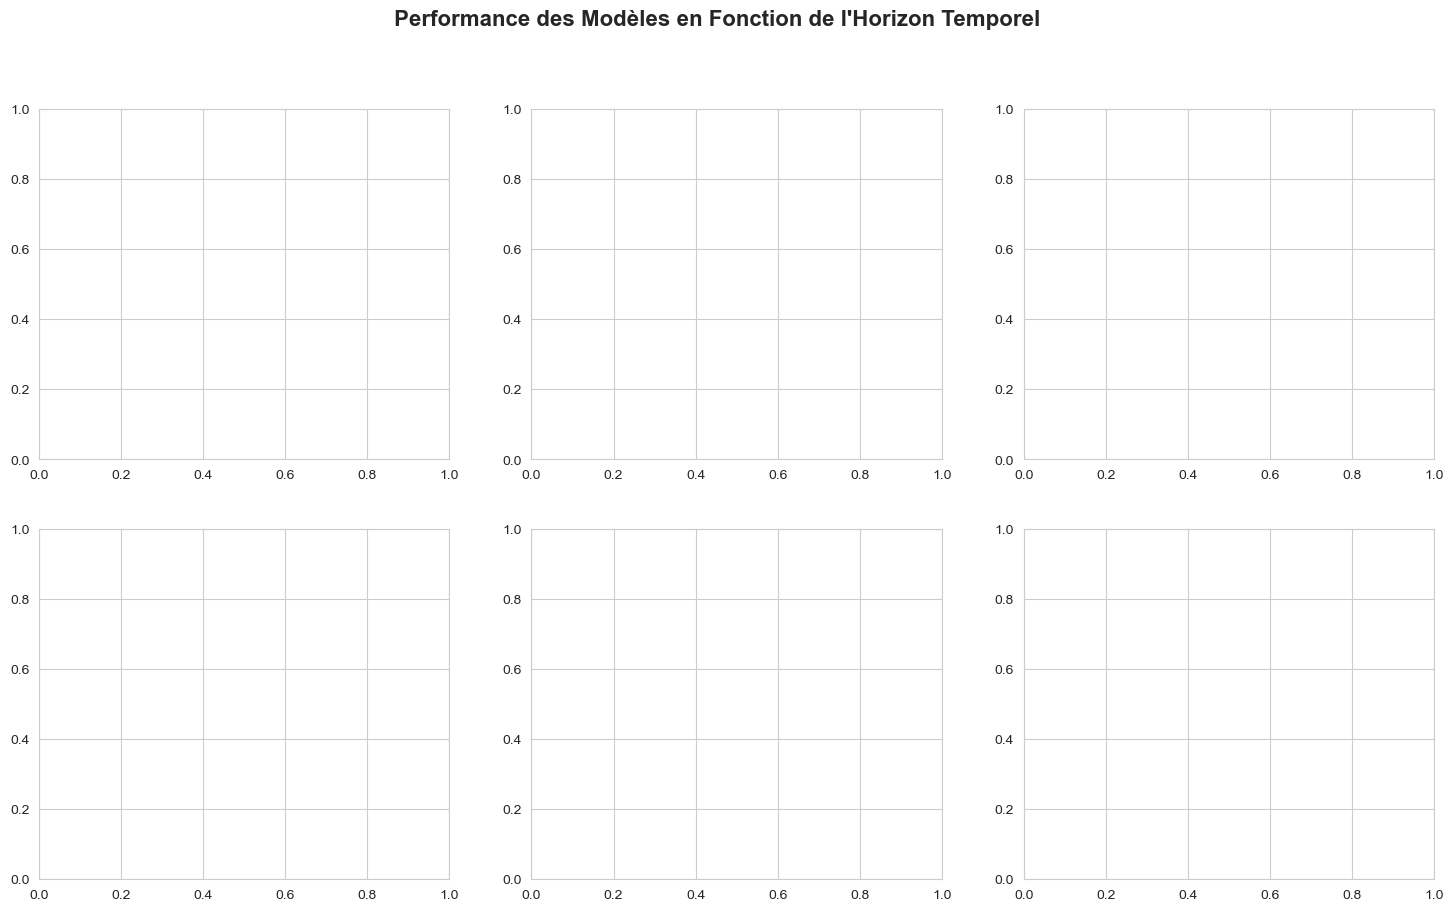

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# VISUALISATIONS COMPLÈTES
# ============================================================

# Supposons que all_results est disponible de l'exécution précédente
# Sinon, charger depuis un pickle

print("="*80)
print(" GÉNÉRATION DES VISUALISATIONS")
print("="*80)

# Style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 12)

# ============================================================
# FIGURE 1: PERFORMANCE EN FONCTION DE L'HORIZON
# ============================================================

fig1, axes = plt.subplots(2, 3, figsize=(18, 10))
fig1.suptitle(" Performance des Modèles en Fonction de l'Horizon Temporel", 
              fontsize=16, fontweight='bold')

horizons = [r["horizon"] for r in all_results]
r2_values = [r["r2"] for r in all_results]
rmse_values = [r["rmse"] for r in all_results]
dir_acc_reg = [r["dir_acc_reg"]*100 for r in all_results]
acc_class = [r["acc_class"]*100 for r in all_results]
mean_returns = [r["return_stats"]["mean"]*100 for r in all_results]
std_returns = [r["return_stats"]["std"]*100 for r in all_results]

# 1. R²
axes[0, 0].plot(horizons, r2_values, 'o-', linewidth=2, markersize=10, color='#2E86AB')
axes[0, 0].axhline(y=0, color='red', linestyle='--', alpha=0.5, label='Baseline')
axes[0, 0].set_xlabel('Horizon (jours)', fontsize=11)
axes[0, 0].set_ylabel('R²', fontsize=11)
axes[0, 0].set_title('R² (Régression)', fontweight='bold')
axes[0, 0].grid(alpha=0.3)
axes[0, 0].legend()

# 2. RMSE
axes[0, 1].plot(horizons, rmse_values, 'o-', linewidth=2, markersize=10, color='#A23B72')
axes[0, 1].set_xlabel('Horizon (jours)', fontsize=11)
axes[0, 1].set_ylabel('RMSE', fontsize=11)
axes[0, 1].set_title('RMSE (Régression)', fontweight='bold')
axes[0, 1].grid(alpha=0.3)

# 3. Directional Accuracy (Régression)
axes[0, 2].plot(horizons, dir_acc_reg, 'o-', linewidth=2, markersize=10, color='#F18F01')
axes[0, 2].axhline(y=50, color='red', linestyle='--', alpha=0.5, label='Hasard (50%)')
axes[0, 2].set_xlabel('Horizon (jours)', fontsize=11)
axes[0, 2].set_ylabel('Accuracy (%)', fontsize=11)
axes[0, 2].set_title('Directional Accuracy (Régression)', fontweight='bold')
axes[0, 2].grid(alpha=0.3)
axes[0, 2].legend()
axes[0, 2].set_ylim(30, 75)

# 4. Accuracy Classification (Scénarios)
axes[1, 0].plot(horizons, acc_class, 'o-', linewidth=2, markersize=10, color='#6A994E')
axes[1, 0].axhline(y=20, color='red', linestyle='--', alpha=0.5, label='Hasard (20%)')
axes[1, 0].set_xlabel('Horizon (jours)', fontsize=11)
axes[1, 0].set_ylabel('Accuracy (%)', fontsize=11)
axes[1, 0].set_title('Accuracy Classification (5 scénarios)', fontweight='bold')
axes[1, 0].grid(alpha=0.3)
axes[1, 0].legend()

# 5. Mean Return
axes[1, 1].plot(horizons, mean_returns, 'o-', linewidth=2, markersize=10, color='#BC4B51')
axes[1, 1].axhline(y=0, color='black', linestyle='-', alpha=0.3)
axes[1, 1].set_xlabel('Horizon (jours)', fontsize=11)
axes[1, 1].set_ylabel('Rendement moyen (%)', fontsize=11)
axes[1, 1].set_title('Rendement Moyen par Horizon', fontweight='bold')
axes[1, 1].grid(alpha=0.3)

# 6. Std Return (Volatilité)
axes[1, 2].plot(horizons, std_returns, 'o-', linewidth=2, markersize=10, color='#8B5A3C')
axes[1, 2].set_xlabel('Horizon (jours)', fontsize=11)
axes[1, 2].set_ylabel('Volatilité (%)', fontsize=11)
axes[1, 2].set_title('Volatilité des Rendements par Horizon', fontweight='bold')
axes[1, 2].grid(alpha=0.3)

plt.tight_layout()

# ============================================================
# FIGURE 2: MATRICES DE CONFUSION (1 SEMAINE)
# ============================================================

# Trouver les résultats pour horizon = 7 jours
res_7d = next((r for r in all_results if r["horizon"] == 7), None)

if res_7d is not None:
    fig2, ax = plt.subplots(1, 1, figsize=(10, 8))
    
    cm = res_7d["confusion_matrix"]
    scenario_names = ["Fort\nBaissier", "Baissier", "Neutre", "Haussier", "Fort\nHaussier"]
    
    # Normaliser par ligne (pourcentage par classe réelle)
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    
    sns.heatmap(cm_normalized, annot=True, fmt='.1f', cmap='YlOrRd', 
                xticklabels=scenario_names, yticklabels=scenario_names,
                cbar_kws={'label': 'Pourcentage (%)'}, ax=ax)
    
    ax.set_xlabel('Scénario Prédit', fontsize=12, fontweight='bold')
    ax.set_ylabel('Scénario Réel', fontsize=12, fontweight='bold')
    ax.set_title('Matrice de Confusion - Horizon 1 Semaine (7 jours)\n(Pourcentages par ligne)', 
                 fontsize=14, fontweight='bold')
    
    plt.tight_layout()

# ============================================================
# FIGURE 3: DISTRIBUTION DES SCÉNARIOS PAR HORIZON
# ============================================================

fig3, axes = plt.subplots(2, 4, figsize=(18, 10))
fig3.suptitle(" Distribution des Scénarios par Horizon Temporel", 
              fontsize=16, fontweight='bold')

axes = axes.flatten()
scenario_names_short = ["Fort Baiss.", "Baissier", "Neutre", "Haussier", "Fort Hauss."]
colors = ['#d62828', '#f77f00', '#fcbf49', '#06d6a0', '#118ab2']

for idx, res in enumerate(all_results):
    if idx < len(axes):
        dist = res["scenario_dist_test"]
        
        # S'assurer que tous les scénarios sont présents
        full_dist = pd.Series([0]*5, index=range(5))
        full_dist.update(dist)
        
        axes[idx].bar(range(5), full_dist.values, color=colors, alpha=0.8, edgecolor='black')
        axes[idx].set_xlabel('Scénario', fontsize=10)
        axes[idx].set_ylabel('Nombre', fontsize=10)
        axes[idx].set_title(f'Horizon {res["horizon"]} jours', fontweight='bold')
        axes[idx].set_xticks(range(5))
        axes[idx].set_xticklabels(scenario_names_short, rotation=45, ha='right', fontsize=8)
        axes[idx].grid(alpha=0.3, axis='y')

# Cacher les axes vides
for idx in range(len(all_results), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()

# ============================================================
# FIGURE 4: ÉVOLUTION DES TOP FEATURES
# ============================================================

# Identifier les 10 features les plus récurrentes
top_recurring_features_reg = sorted_features_reg[:10]

fig4, ax = plt.subplots(1, 1, figsize=(14, 8))

# Pour chaque feature récurrente, tracer son importance en fonction de l'horizon
for feat, _ in top_recurring_features_reg:
    if feat in all_features_reg:
        horizons_feat = [h for h, _ in all_features_reg[feat]]
        importances_feat = [imp for _, imp in all_features_reg[feat]]
        
        ax.plot(horizons_feat, importances_feat, 'o-', label=feat, linewidth=2, markersize=8)

ax.set_xlabel('Horizon (jours)', fontsize=12, fontweight='bold')
ax.set_ylabel('Importance', fontsize=12, fontweight='bold')
ax.set_title('Évolution de l\'Importance des Top 10 Features (Régression)', 
             fontsize=14, fontweight='bold')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()

# ============================================================
# FIGURE 5: PRÉDICTIONS VS RÉALITÉ (HORIZON 7j et 30j)
# ============================================================

fig5, axes = plt.subplots(1, 2, figsize=(16, 6))

# Horizon 7 jours
res_7d = next((r for r in all_results if r["horizon"] == 7), None)
if res_7d:
    y_true = res_7d["y_reg_test"].values * 100  # Convertir en %
    y_pred = res_7d["y_reg_pred"] * 100
    
    axes[0].scatter(y_true, y_pred, alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
    
    # Ligne de prédiction parfaite
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Prédiction parfaite')
    
    axes[0].set_xlabel('Rendement Réel (%)', fontsize=11, fontweight='bold')
    axes[0].set_ylabel('Rendement Prédit (%)', fontsize=11, fontweight='bold')
    axes[0].set_title(f'Horizon 7 jours (R²={res_7d["r2"]:.3f})', fontweight='bold')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

# Horizon 30 jours
res_30d = next((r for r in all_results if r["horizon"] == 30), None)
if res_30d:
    y_true = res_30d["y_reg_test"].values * 100
    y_pred = res_30d["y_reg_pred"] * 100
    
    axes[1].scatter(y_true, y_pred, alpha=0.6, s=50, edgecolors='black', linewidth=0.5, color='orange')
    
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    axes[1].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Prédiction parfaite')
    
    axes[1].set_xlabel('Rendement Réel (%)', fontsize=11, fontweight='bold')
    axes[1].set_ylabel('Rendement Prédit (%)', fontsize=11, fontweight='bold')
    axes[1].set_title(f'Horizon 30 jours (R²={res_30d["r2"]:.3f})', fontweight='bold')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

plt.tight_layout()

print("\n" + "="*80)
print(" TOUTES LES VISUALISATIONS GÉNÉRÉES")
print("="*80)

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Choisis l'horizon que tu veux voir
horizon_choisi = 30  # Change ça pour 14, 30, 60, 90, 120, 150

# Trouve les résultats pour cet horizon
res = next((r for r in all_results if r["horizon"] == horizon_choisi), None)

if res is not None:
    # Récupère la matrice de confusion
    cm = res["confusion_matrix"]
    
    # Noms des scénarios
    scenario_names = ["Fort\nBaissier", "Baissier", "Neutre", "Haussier", "Fort\nHaussier"]
    
    # Normalise par ligne (pourcentage par classe réelle)
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    
    # Crée la figure
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm_normalized, 
                annot=True,           # Affiche les valeurs
                fmt='.1f',            # 1 décimale
                cmap='YlOrRd',        # Palette de couleurs
                xticklabels=scenario_names, 
                yticklabels=scenario_names,
                cbar_kws={'label': 'Pourcentage (%)'},
                vmin=0, vmax=100)
    
    plt.xlabel('Scénario Prédit', fontsize=12, fontweight='bold')
    plt.ylabel('Scénario Réel', fontsize=12, fontweight='bold')
    plt.title(f'Matrice de Confusion - Horizon {horizon_choisi} jours\n(Pourcentages par ligne)', 
              fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Affiche aussi les valeurs brutes
    print(f"\n Matrice Brute (Nombre d'échantillons):")
    print(cm)
    
    # Affiche l'accuracy
    accuracy = np.trace(cm) / np.sum(cm) * 100
    print(f"\n Accuracy: {accuracy:.1f}%")
else:
    print(f" Pas de résultats pour horizon {horizon_choisi}j")

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Choisis ton horizon
horizon_choisi = 14  # Change pour 14, 30, 60, 90, 120, 150

# Trouve les résultats
res = next((r for r in all_results if r["horizon"] == horizon_choisi), None)

if res is not None:
    # Récupère la matrice de confusion de la CLASSIFICATION
    cm = res["confusion_matrix"]
    
    # CORRECTION : Adapte les noms selon la taille réelle de la matrice
    scenario_names_full = ["Fort Baissier", "Baissier", "Neutre", "Haussier", "Fort Haussier"]
    
    # Nombre de scénarios réellement présents
    n_scenarios = cm.shape[0]
    
    # Prend seulement les noms correspondants
    scenario_names = [scenario_names_full[i] for i in range(n_scenarios)]
    scenario_names_plot = [s.replace(" ", "\n") for s in scenario_names]
    
    # Normalise par ligne (% par classe réelle)
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    
    # Crée la figure
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm_normalized, 
                annot=True,
                fmt='.1f',
                cmap='RdYlGn',
                xticklabels=scenario_names_plot, 
                yticklabels=scenario_names_plot,
                cbar_kws={'label': 'Pourcentage (%)'},
                vmin=0, vmax=100)
    
    plt.xlabel('Scénario Prédit (Classification)', fontsize=12, fontweight='bold')
    plt.ylabel('Scénario Réel', fontsize=12, fontweight='bold')
    plt.title(f'Matrice de Confusion - Classification\nHorizon {horizon_choisi} jours ({n_scenarios} scénarios présents)', 
              fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Stats
    accuracy = np.trace(cm) / np.sum(cm) * 100
    print(f"\n Accuracy Classification: {accuracy:.1f}%")
    print(f" Nombre total d'échantillons: {np.sum(cm)}")
    print(f" Nombre de scénarios présents: {n_scenarios}/5")
    
    # Distribution des prédictions
    print(f"\n Distribution des PRÉDICTIONS:")
    pred_dist = cm.sum(axis=0)
    for i in range(len(pred_dist)):
        pct = (pred_dist[i] / pred_dist.sum()) * 100
        print(f"   {scenario_names[i]}: {pred_dist[i]} ({pct:.1f}%)")
    
    # Distribution des réalités
    print(f"\n Distribution des RÉALITÉS:")
    real_dist = cm.sum(axis=1)
    for i in range(len(real_dist)):
        pct = (real_dist[i] / real_dist.sum()) * 100
        print(f"   {scenario_names[i]}: {real_dist[i]} ({pct:.1f}%)")
    
    # Scénarios manquants
    if n_scenarios < 5:
        missing = [scenario_names_full[i] for i in range(5) if i >= n_scenarios or i not in range(n_scenarios)]
        print(f"\n Scénarios ABSENTS du test set:")
        for m in missing:
            print(f"   • {m}")
else:
    print(f" Pas de résultats pour horizon {horizon_choisi}j")

## test causality

In [ ]:
pip install graphviz 

In [ ]:
# ===============================
# CAUSAL PIPELINE (DoWhy) - VERSION CORRIGÉE v2
# ===============================

import pandas as pd
import numpy as np

# 1) Base DF
df = pivot_df.copy()

# Ensure datetime index
df.index = pd.to_datetime(df.index)

# 2) Create BTC log-return + horizon target (choose one)
HORIZON = 7  # change to 1, 7, 30, etc.

if "XBTUSD Curncy" not in df.columns:
    raise ValueError("BTC price column 'XBTUSD Curncy' missing.")

df["BTC_logret"] = np.log(df["XBTUSD Curncy"]).diff()

# Target = cumulative log-return over next HORIZON days
df["target"] = df["BTC_logret"].rolling(HORIZON).sum().shift(-HORIZON)

# Drop only where target or BTC is missing
df = df.dropna(subset=["BTC_logret", "target"])

# 3) OPTIONAL: filter date (if you want after 2018)
# df = df[df.index >= "2018-03-01"]

# 4) Fill missing values in features (important for macro series)
df = df.ffill().bfill()

# Remove columns you don't want as features
drop_cols = ["BTC_logret", "XBTUSD Curncy"]  # keep target

# -------------------------------
# Choose treatment candidates
# -------------------------------
treatments = [
    "VIX Index",
    "MOVE Index",
    "DXY Curncy",
    "USYC2Y10 Index",
    "DEYC2Y10 Index"
]

# keep only treatments present
treatments = [t for t in treatments if t in df.columns]
print("Treatments available:", treatments)

# -------------------------------
# Choose confounders (controls)
# -------------------------------
confounders = []
candidate_confounders = [
    "SPX Index", "CCMP Index", "RTY Index",
    "CL1 COMB Comdty", "NG1 COMB Comdty",
    "EURUSD Curncy", "JPYUSD Curncy", "CNH Curncy",
    "M2 Index", "ECMAM2 Index",
    "WGDPUS Index", "WGDPEURO Index"
]

confounders = [c for c in candidate_confounders if c in df.columns]
print("Confounders used:", confounders)

# -------------------------------
# Make causal dataset
# -------------------------------
causal_df = df[["target"] + treatments + confounders].copy()

# Ensure numeric
for col in causal_df.columns:
    causal_df[col] = pd.to_numeric(causal_df[col], errors="coerce")

causal_df = causal_df.dropna()
print("Causal df shape:", causal_df.shape)

# ===============================
# DoWhy Causal Estimation - SOLUTION GML FORMAT
# ===============================
from dowhy import CausalModel

results = []

for T in treatments:
    print("\n==============================")
    print("Treatment:", T, "| Outcome: target | Horizon:", HORIZON)

    # --------------------------
    # Créer le graphe en format GML (celui qui marche!)
    # --------------------------
    gml_graph = "graph [\n  directed 1\n"
    
    # Ajouter les nœuds
    gml_graph += f'  node [ id "{T}" label "{T}" ]\n'
    gml_graph += f'  node [ id "target" label "target" ]\n'
    
    for c in confounders:
        gml_graph += f'  node [ id "{c}" label "{c}" ]\n'
    
    # Ajouter les arêtes
    for c in confounders:
        gml_graph += f'  edge [ source "{c}" target "{T}" ]\n'
        gml_graph += f'  edge [ source "{c}" target "target" ]\n'
    
    gml_graph += f'  edge [ source "{T}" target "target" ]\n'
    gml_graph += "]\n"

    # Créer le modèle avec le graphe GML
    model = CausalModel(
        data=causal_df,
        treatment=T,
        outcome="target",
        graph=gml_graph
    )

    identified_estimand = model.identify_effect(proceed_when_unidentifiable=True)
    print("Identified estimand:", identified_estimand)

    # --------------------------
    # Estimate effect (backdoor)
    # --------------------------
    estimate = model.estimate_effect(
        identified_estimand,
        method_name="backdoor.linear_regression"
    )

    print("Causal estimate (ATE):", estimate.value)

    # --------------------------
    # Refutation tests
    # --------------------------
    try:
        ref_placebo = model.refute_estimate(
            identified_estimand, estimate,
            method_name="placebo_treatment_refuter",
            placebo_type="permute"
        )
        placebo_new_est = getattr(ref_placebo, "new_effect", None)
        placebo_p = None
        if hasattr(ref_placebo, 'refutation_result'):
            placebo_p = ref_placebo.refutation_result.get('p_value', None)
        print("\nRefutation — placebo:", ref_placebo)
    except Exception as e:
        print(f"Placebo test failed: {e}")
        placebo_new_est = None
        placebo_p = None

    try:
        ref_randomcc = model.refute_estimate(
            identified_estimand, estimate,
            method_name="random_common_cause"
        )
        randomcc_new_est = getattr(ref_randomcc, "new_effect", None)
        print("Refutation — random common cause:", ref_randomcc)
    except Exception as e:
        print(f"Random common cause test failed: {e}")
        randomcc_new_est = None

    try:
        ref_subset = model.refute_estimate(
            identified_estimand, estimate,
            method_name="data_subset_refuter",
            subset_fraction=0.8
        )
        subset_new_est = getattr(ref_subset, "new_effect", None)
        print("Refutation — data subset:", ref_subset)
    except Exception as e:
        print(f"Subset test failed: {e}")
        subset_new_est = None

    results.append({
        "Horizon": HORIZON,
        "Treatment": T,
        "ATE": estimate.value,
        "Placebo_new_est": placebo_new_est,
        "Placebo_p": placebo_p,
        "RandomCC_new_est": randomcc_new_est,
        "Subset_new_est": subset_new_est
    })

# ===============================
# Results table
# ===============================
results_df = pd.DataFrame(results).sort_values("ATE", ascending=False, key=abs)
print("\n=== SUMMARY RESULTS ===")
display(results_df)

# Optional: save
# results_df.to_csv(f"causal_results_h{HORIZON}.csv", index=False)
# print(f"Saved: causal_results_h{HORIZON}.csv")

In [ ]:
# ===============================
# CAUSAL PIPELINE
# ===============================

import pandas as pd
import numpy as np
from dowhy import CausalModel

# 1) Base DF
df = pivot_df.copy()
df.index = pd.to_datetime(df.index)

# =================================
HORIZON = 30  # 1, 7, 30, 90, etc.
# =================================

if "XBTUSD Curncy" not in df.columns:
    raise ValueError("BTC price column 'XBTUSD Curncy' missing.")

df["BTC_logret"] = np.log(df["XBTUSD Curncy"]).diff()
df["target"] = df["BTC_logret"].rolling(HORIZON).sum().shift(-HORIZON)
df = df.dropna(subset=["BTC_logret", "target"])
df = df.ffill().bfill()

# Treatments
treatments = [
    "VIX Index",
    "MOVE Index", 
    "DXY Curncy",
    "USYC2Y10 Index",
    "DEYC2Y10 Index"
]
treatments = [t for t in treatments if t in df.columns]

# Confounders
candidate_confounders = [
    "SPX Index", "CCMP Index", "RTY Index",
    "CL1 COMB Comdty", "NG1 COMB Comdty",
    "EURUSD Curncy", "JPYUSD Curncy", "CNH Curncy",
    "M2 Index", "ECMAM2 Index",
    "WGDPUS Index", "WGDPEURO Index"
]
confounders = [c for c in candidate_confounders if c in df.columns]

# Causal dataset
causal_df = df[["target"] + treatments + confounders].copy()
for col in causal_df.columns:
    causal_df[col] = pd.to_numeric(causal_df[col], errors="coerce")
causal_df = causal_df.dropna()

print(f"\n{'='*50}")
print(f"HORIZON: {HORIZON} days | Sample size: {len(causal_df)}")
print(f"{'='*50}\n")

# ===============================
# LOOP - AFFICHAGE MINIMAL
# ===============================

results = []

for T in treatments:
    # Build GML graph
    gml_graph = "graph [\n  directed 1\n"
    gml_graph += f'  node [ id "{T}" label "{T}" ]\n'
    gml_graph += f'  node [ id "target" label "target" ]\n'
    
    for c in confounders:
        gml_graph += f'  node [ id "{c}" label "{c}" ]\n'
    
    for c in confounders:
        gml_graph += f'  edge [ source "{c}" target "{T}" ]\n'
        gml_graph += f'  edge [ source "{c}" target "target" ]\n'
    
    gml_graph += f'  edge [ source "{T}" target "target" ]\n'
    gml_graph += "]\n"

    # Causal model
    model = CausalModel(
        data=causal_df,
        treatment=T,
        outcome="target",
        graph=gml_graph
    )

    identified_estimand = model.identify_effect(proceed_when_unidentifiable=True)
    estimate = model.estimate_effect(
        identified_estimand,
        method_name="backdoor.linear_regression"
    )

    # Refutation tests (silent)
    try:
        ref_placebo = model.refute_estimate(
            identified_estimand, estimate,
            method_name="placebo_treatment_refuter",
            placebo_type="permute"
        )
        placebo_new_est = getattr(ref_placebo, "new_effect", None)
        placebo_p = ref_placebo.refutation_result.get('p_value', None) if hasattr(ref_placebo, 'refutation_result') else None
    except:
        placebo_new_est = None
        placebo_p = None

    try:
        ref_randomcc = model.refute_estimate(
            identified_estimand, estimate,
            method_name="random_common_cause"
        )
        randomcc_new_est = getattr(ref_randomcc, "new_effect", None)
    except:
        randomcc_new_est = None

    try:
        ref_subset = model.refute_estimate(
            identified_estimand, estimate,
            method_name="data_subset_refuter",
            subset_fraction=0.8
        )
        subset_new_est = getattr(ref_subset, "new_effect", None)
    except:
        subset_new_est = None

    results.append({
        "Horizon": HORIZON,
        "Treatment": T,
        "ATE": estimate.value,
        "Placebo_new_est": placebo_new_est,
        "Placebo_p": placebo_p,
        "RandomCC_new_est": randomcc_new_est,
        "Subset_new_est": subset_new_est
    })
    
    # Affichage minimal par traitement
    print(f"{T:20s} | ATE: {estimate.value:10.6f}")

# ===============================
# RESULTS
# ===============================
results_df = pd.DataFrame(results).sort_values("ATE", ascending=False, key=abs)

print(f"\n{'='*50}")
print("=== SUMMARY RESULTS ===")
print(f"{'='*50}")
display(results_df)

# Save
results_df.to_csv(f"causal_results_h{HORIZON}.csv", index=False)
print(f"\n✓ Saved: causal_results_h{HORIZON}.csv")